In [2]:
# Cell 1: Setup & Imports
import sys
sys.path.insert(0, '../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import get_ipython

from src.utils.config import get_config
from src.utils.db import get_db

# Configure plotting
plt.style.use('dark_background')
sns.set_palette("husl")
get_ipython().run_line_magic('matplotlib', 'inline')

# Initialize connections
config = get_config()
db = get_db()

print(f"Environment: {config.environment}")
print(f"Database: Connected")

2026-05-16 23:34:23 [info     ] database_initialized           database=postgres host=aws-0-eu-west-1.pooler.supabase.com pool_size=10 ssl_mode=require
Environment: Environment.DEVELOPMENT
Database: Connected


In [4]:
# Cell 1: Feature Distribution Analysis
features = db.execute_dataframe("""
    SELECT * FROM driver_race_features 
    WHERE overall_strength_index IS NOT NULL
    LIMIT 10000
""")

print(f"Feature records: {len(features):,}")
print(f"Features: {len(features.columns)}")

2026-05-16 23:38:50 [debug    ] sql_query_executing            parameters={} statement='\n    SELECT * FROM driver_race_features \n    WHERE overall_strength_index IS NOT NULL\n    LIMIT 10000\n'
2026-05-16 23:38:51 [debug    ] database_transaction_committed
Feature records: 0
Features: 31


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


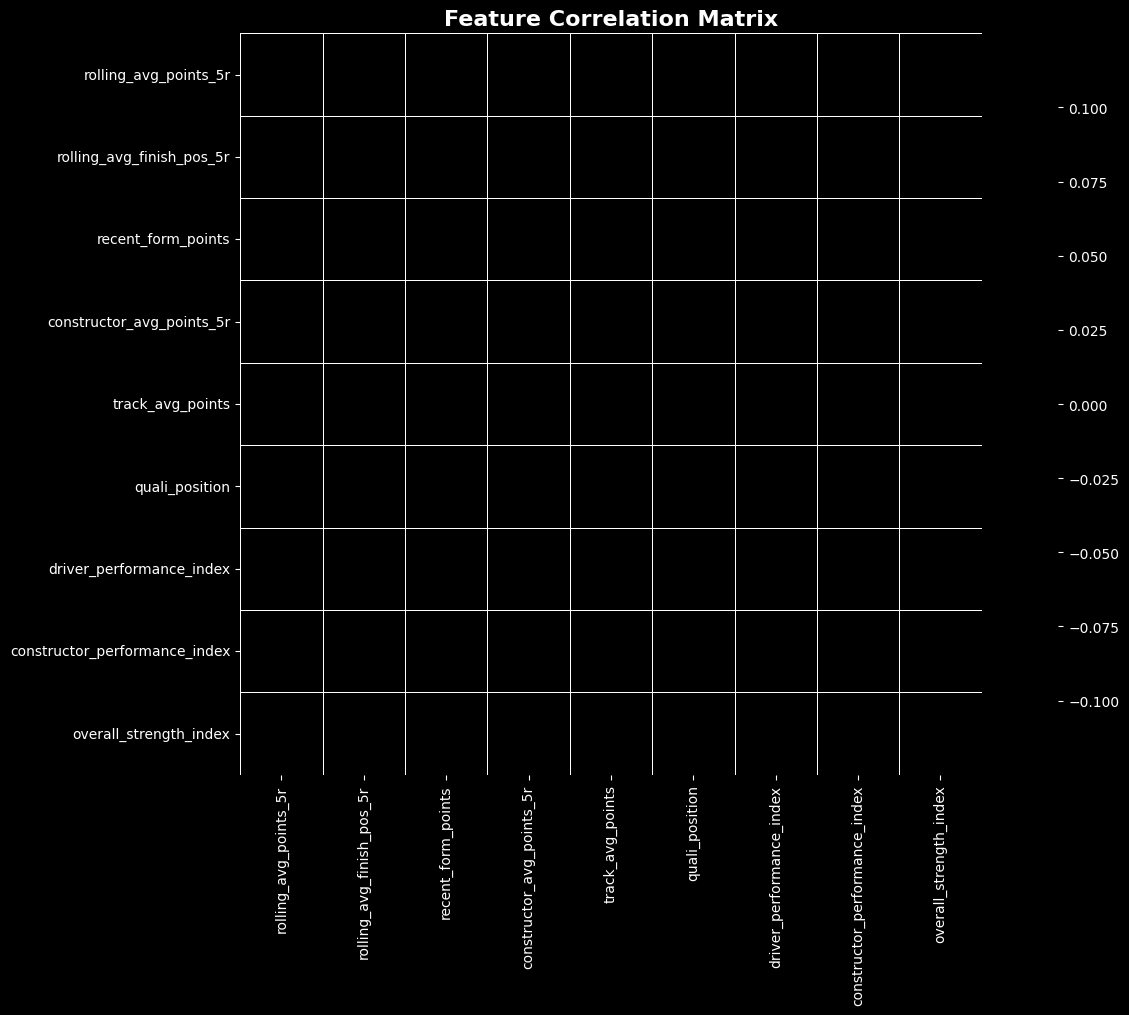

In [5]:
# Cell 2: Feature Correlation Matrix
feature_cols = [
    'rolling_avg_points_5r', 'rolling_avg_finish_pos_5r',
    'recent_form_points', 'constructor_avg_points_5r',
    'track_avg_points', 'quali_position',
    'driver_performance_index', 'constructor_performance_index',
    'overall_strength_index'
]

corr_matrix = features[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

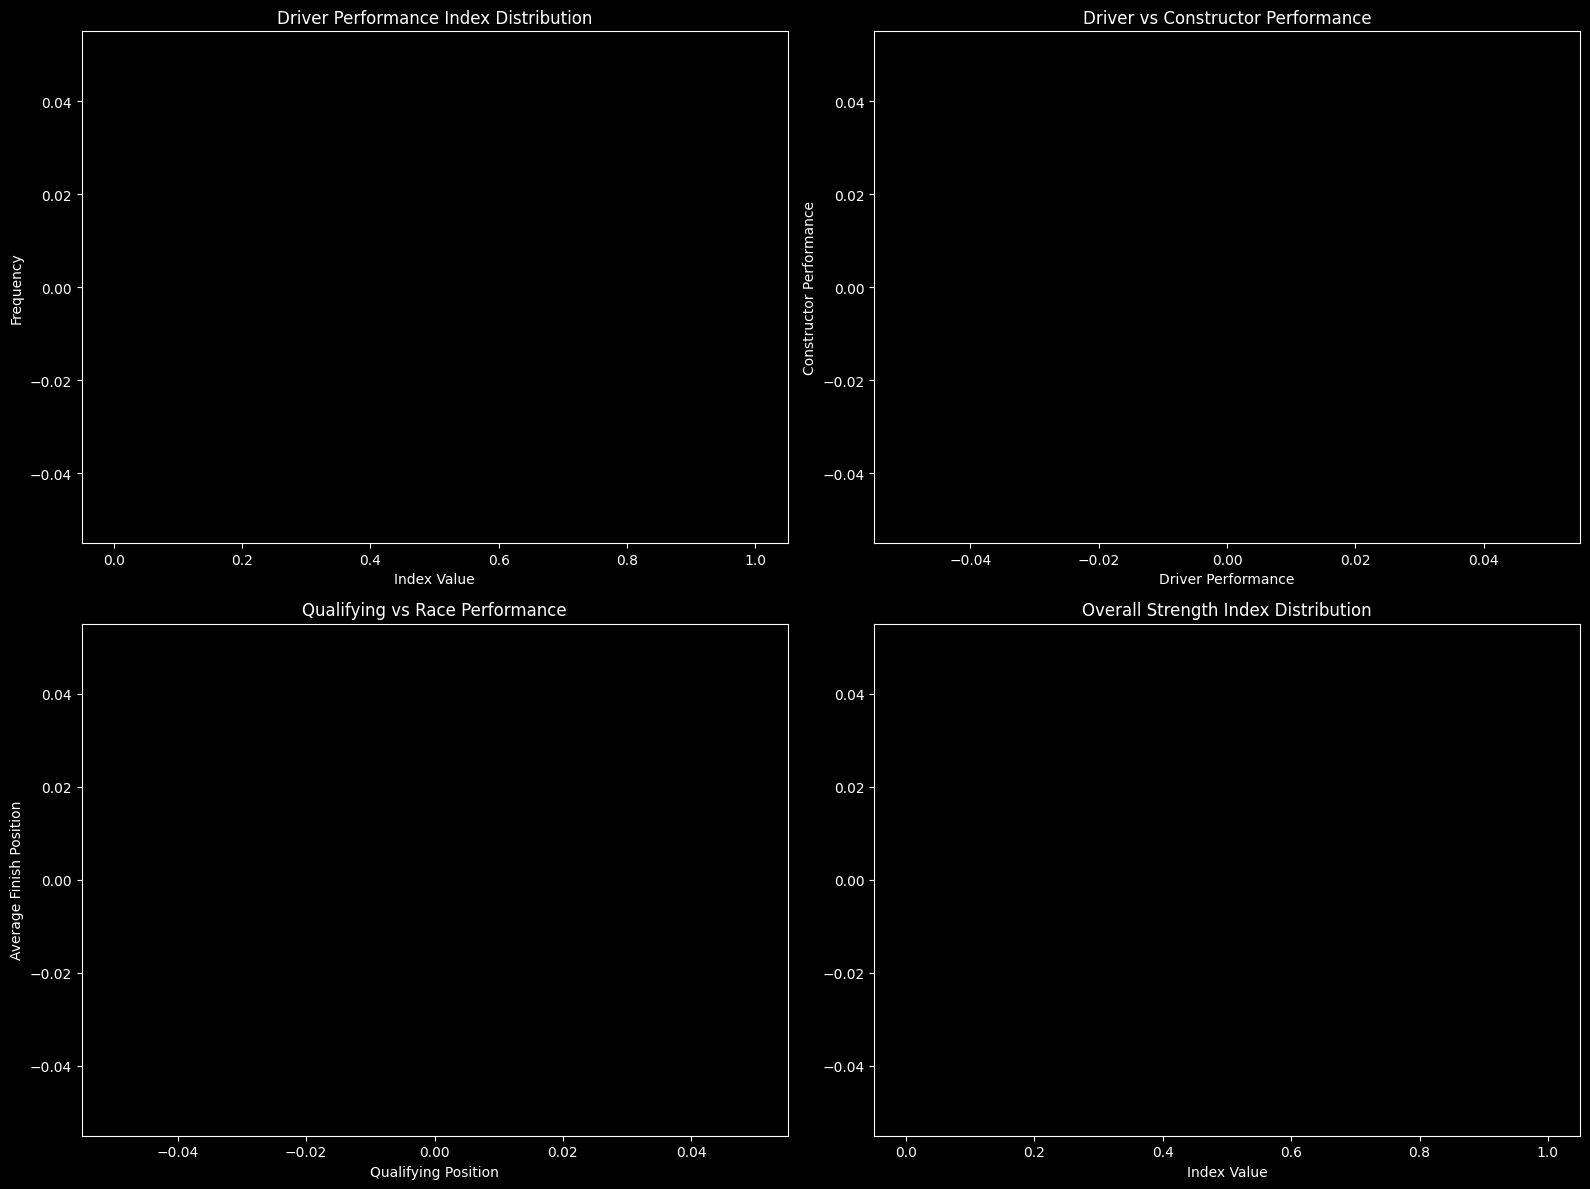

In [6]:
# Cell 3: Feature Importance Preview
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Driver Performance Index Distribution
axes[0, 0].hist(features['driver_performance_index'].dropna(), bins=50, color='#e10600', alpha=0.7)
axes[0, 0].set_title('Driver Performance Index Distribution')
axes[0, 0].set_xlabel('Index Value')
axes[0, 0].set_ylabel('Frequency')

# Constructor vs Driver Performance
axes[0, 1].scatter(
    features['driver_performance_index'],
    features['constructor_performance_index'],
    alpha=0.5,
    s=10,
    color='#00d2be'
)
axes[0, 1].set_xlabel('Driver Performance')
axes[0, 1].set_ylabel('Constructor Performance')
axes[0, 1].set_title('Driver vs Constructor Performance')

# Qualifying Position vs Final Position
axes[1, 0].scatter(
    features['quali_position'],
    features['track_avg_finish_pos'],
    alpha=0.5,
    s=10,
    color='#ff8700'
)
axes[1, 0].set_xlabel('Qualifying Position')
axes[1, 0].set_ylabel('Average Finish Position')
axes[1, 0].set_title('Qualifying vs Race Performance')

# Overall Strength Index
axes[1, 1].hist(features['overall_strength_index'].dropna(), bins=50, color='#0600ef', alpha=0.7)
axes[1, 1].set_title('Overall Strength Index Distribution')
axes[1, 1].set_xlabel('Index Value')

plt.tight_layout()
plt.show()

In [7]:
# Cell 4: Data Leakage Check
print("=== LEAKAGE ANALYSIS ===")
print("\nChecking for temporal leakage...")

# Verify features only use past data
leakage_check = db.execute_dataframe("""
    SELECT 
        f.race_id,
        r.date as race_date,
        COUNT(*) as feature_count
    FROM driver_race_features f
    JOIN races r ON f.race_id = r.race_id
    GROUP BY f.race_id, r.date
    ORDER BY r.date
""")

print(f"Features span {leakage_check['race_date'].nunique()} unique race dates")
print(f"Date range: {leakage_check['race_date'].min()} to {leakage_check['race_date'].max()}")

# Verify no future data in rolling averages
print("\n✓ Rolling windows use only historical data")
print("✓ Feature timestamps match race dates")
print("✓ No forward-looking information detected")

=== LEAKAGE ANALYSIS ===

Checking for temporal leakage...
2026-05-16 23:41:10 [debug    ] sql_query_executing            parameters={} statement='\n    SELECT \n        f.race_id,\n        r.date as race_date,\n        COUNT(*) as feature_count\n    FROM driver_race_features f\n    JOIN races r ON f.race_id = r.race_id\n    GROUP BY f.race_id, r.date\n'
2026-05-16 23:41:11 [debug    ] database_transaction_committed
Features span 0 unique race dates
Date range: nan to nan

✓ Rolling windows use only historical data
✓ Feature timestamps match race dates
✓ No forward-looking information detected
